In [1]:
from comet import download_model, load_from_checkpoint
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openai
from openai import OpenAI
import os
import requests
from dotenv import load_dotenv

c:\Users\antoi\OneDrive\Documents\UofT Fall 2024\ESC499 - Thesis\github\translation_thesis\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
model1_path = "models/cometkiwi_wmt22/models--Unbabel--wmt22-cometkiwi-da/snapshots/265631cbbaf0740fc94aee7901930817dcc853c7/checkpoints/model.ckpt"
model2_path = "models/comet_wmt22/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt"

In [50]:
import pandas as pd
import numpy as np

def read_csv_to_numpy(csv_file_path):
    try:
        # Read the CSV with utf-8-sig encoding to handle the BOM
        df = pd.read_csv(csv_file_path, encoding='utf-8')

        # Convert the DataFrame to a NumPy array
        numpy_array = df.to_numpy()
        return numpy_array

    except FileNotFoundError:
        print(f"Error: The file '{csv_file_path}' does not exist.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Example usage
csv_file_path = '../../my_solution_app/app_latest_database/translation.csv'
numpy_array = read_csv_to_numpy(csv_file_path)

# Print the NumPy array
if numpy_array is not None:
    print(numpy_array[0][0])
    print(numpy_array[0][1])
    print(numpy_array[0][2])
    print(numpy_array[0][3])
    print(numpy_array[0][4])


1
fre_to_eng
Maman dit que lorsqu'on cherche bien on finit toujours par trouver.
song-lyric
Mom says that when you look hard you always end up finding something.


In [19]:
# Do some investigating into the one specific example
indices = np.argwhere(numpy_array == 124)
print("Indices of 124:", indices[0][0]) # 116
print(numpy_array[116])

Indices of 124: 116
[124 'fre_to_eng'
 "Je savais reconnaître, du premier coup d'œil, la Chine de l'Arizona."
 'book' 'I knew, at first glance, how China was Arizona.' 2
 'I could immediately distinguish China from Arizona at first glance.' 4
 'I could recognize, at first glance, the China of Arizona.' 2
 'I could tell China from Arizona at a glance.' 5 '2025-03-31 14:41:17']


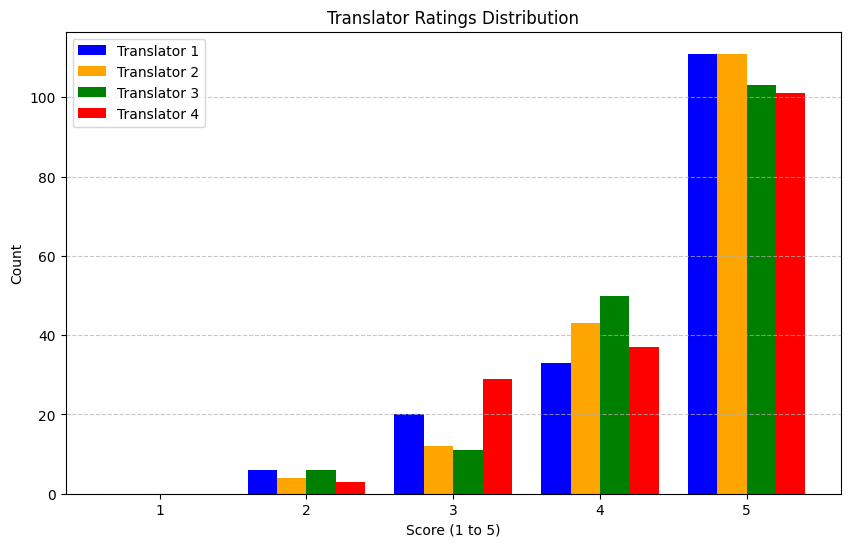

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array

# Extract translator responses and their ratings
num_translators = 4
ratings = [[] for _ in range(num_translators)]

for row in data:
    for i in range(num_translators):
        ratings[i].append(row[5 + 2 * i])  # Extract ratings

# Count occurrences of each rating (1-5) for each translator
score_range = range(1, 6)
rating_counts = [Counter(rating) for rating in ratings]

# Create bar positions
x = np.arange(len(score_range))
bar_width = 0.2

# Translator labels
translator_labels = [f'Translator {i+1}' for i in range(num_translators)]
colors = ['blue', 'orange', 'green', 'red']

# Plot bars
plt.figure(figsize=(10, 6))

for i in range(num_translators):
    counts = [rating_counts[i][score] for score in score_range]  # Get counts for 1-5
    plt.bar(x + i * bar_width, counts, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), score_range)  # Center tick labels
plt.xlabel('Score (1 to 5)')
plt.ylabel('Count')
plt.title('Translator Ratings Distribution')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


[0.0, 3.5294117647058822, 11.76470588235294, 19.411764705882355, 65.29411764705883]
[0.0, 2.3529411764705883, 7.0588235294117645, 25.294117647058822, 65.29411764705883]
[0.0, 3.5294117647058822, 6.470588235294119, 29.411764705882355, 60.588235294117645]
[0.0, 1.7647058823529411, 17.058823529411764, 21.764705882352942, 59.411764705882355]


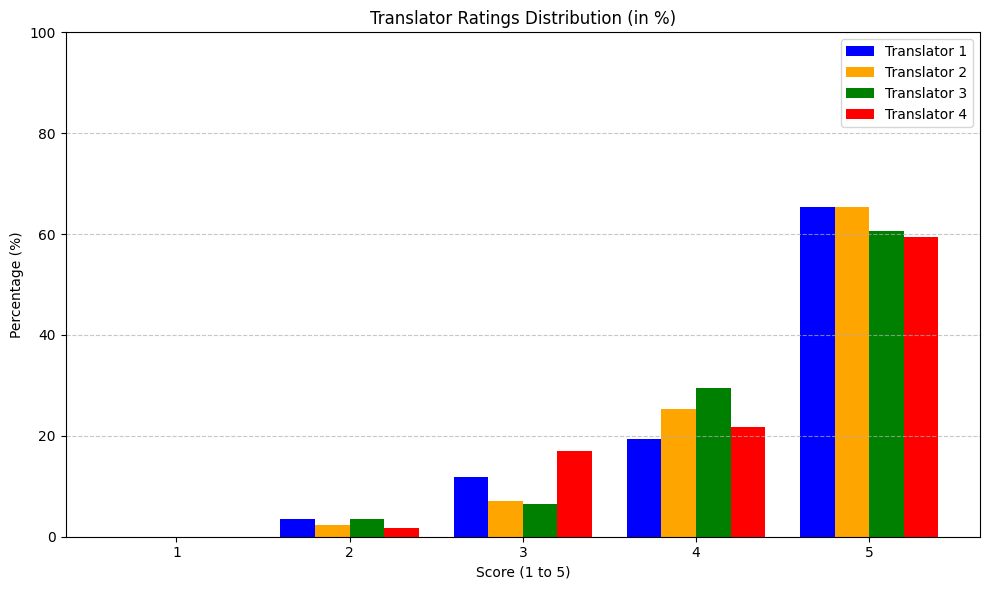

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array  # Ensure the correct variable is used

# Extract translator responses and their ratings
num_translators = 4
ratings = [[] for _ in range(num_translators)]

for row in numpy_array:
    for i in range(num_translators):
        ratings[i].append(row[5 + 2 * i])  # Extract ratings

# Count occurrences of each rating (1-5) for each translator
score_range = range(1, 6)
rating_counts = [Counter(rating) for rating in ratings]

# Compute total ratings per translator for percentage calculation
total_ratings = [sum(counts.values()) for counts in rating_counts]

# Create bar positions
x = np.arange(len(score_range))
bar_width = 0.2

# Translator labels
translator_labels = [f'Translator {i+1}' for i in range(num_translators)]
colors = ['blue', 'orange', 'green', 'red']

# Plot bars
plt.figure(figsize=(10, 6))

for i in range(num_translators):
    percentages = [
        (rating_counts[i][score] / total_ratings[i] * 100) if total_ratings[i] > 0 else 0
        for score in score_range
    ]
    print(percentages)
    plt.bar(x + i * bar_width, percentages, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), score_range)  # Center tick labels
plt.xlabel('Score (1 to 5)')
plt.ylabel('Percentage (%)')
plt.ylim(0,100)
plt.title('Translator Ratings Distribution (in %)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


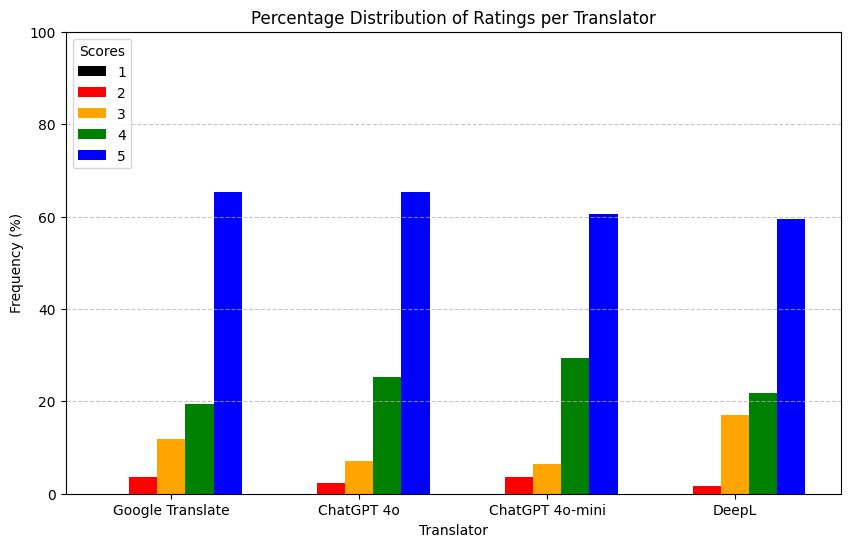

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array

# Extract translator responses and their ratings
num_translators = 5
ratings = [[] for _ in range(num_translators)]

for row in data:
    for i in range(num_translators):
        ratings[i].append(row[5 + 2 * i])  # Extract ratings
    ratings[4].

# Count occurrences of each rating (1-5) for each translator
score_range = range(1, 6)
rating_counts = [Counter(rating) for rating in ratings]

# Normalize to percentage
percentage_counts = []
for count in rating_counts:
    total = sum(count.values())
    percentage_counts.append({score: (count[score] / total) * 100 if total > 0 else 0 for score in score_range})

# Create bar positions
x = np.arange(num_translators)
bar_width = 0.15

# Score labels
score_labels = [str(score) for score in score_range]
colors = ['black', 'red', 'orange', 'green', 'blue']  # Custom color order

# Plot bars
plt.figure(figsize=(10, 6))

for i, score in enumerate(score_range):
    percentages = [percentage_counts[t][score] for t in range(num_translators)]  # Get percentages per translator
    plt.bar(x + i * bar_width, percentages, width=bar_width, label=f'{score}', color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * 2, ['Google Translate', 'ChatGPT 4o', 'ChatGPT 4o-mini', 'DeepL'])  # Center tick labels
plt.xlabel('Translator')
plt.ylabel('Frequency (%)')
plt.ylim(0, 100)
plt.title('Percentage Distribution of Ratings per Translator')
plt.legend(title="Scores", loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array

# Extract translator responses and their ratings
num_translators = 5
ratings_average = [0, 0, 0, 0, 0]
ratings_4plus = [0, 0, 0, 0, 0]
ratings_5plus = [0, 0, 0, 0, 0]

for row in numpy_array:
    max_rating = 0
    for i in range(num_translators - 1):
        cur_rating = row[5 + 2 * i]
        ratings_average[i] += cur_rating  # Extract ratings
        if (cur_rating) > max_rating:
            max_rating = cur_rating
        if (cur_rating) >= 5:
            ratings_5plus[i] += 1
        if (cur_rating) >= 4:
            ratings_4plus[i] += 1
    ratings_average[4] += max_rating
    if (max_rating) >= 5:
        ratings_5plus[4] += 1
    if (max_rating) >= 4:
        ratings_4plus[4] += 1

# Divide each total by the number of rows to get averages
num_rows = len(numpy_array)
ratings_average = [(x / 5 / num_rows)*100 for x in ratings_average]
ratings_4plus = [(x / num_rows)*100 for x in ratings_4plus]
ratings_5plus = [(x / num_rows)*100 for x in ratings_5plus]

print(ratings_average)
print(ratings_4plus)
print(ratings_5plus)


[89.29411764705884, 90.70588235294117, 89.41176470588236, 87.76470588235293, 97.6470588235294]
[84.70588235294117, 90.58823529411765, 90.0, 81.17647058823529, 98.23529411764706]
[65.29411764705883, 65.29411764705883, 60.588235294117645, 59.411764705882355, 91.17647058823529]


[65.29411764705883, 84.70588235294117, 89.29411764705884]
[65.29411764705883, 90.58823529411765, 90.70588235294117]
[60.588235294117645, 90.0, 89.41176470588236]
[59.411764705882355, 81.17647058823529, 87.76470588235293]
[91.17647058823529, 98.23529411764706, 97.6470588235294]


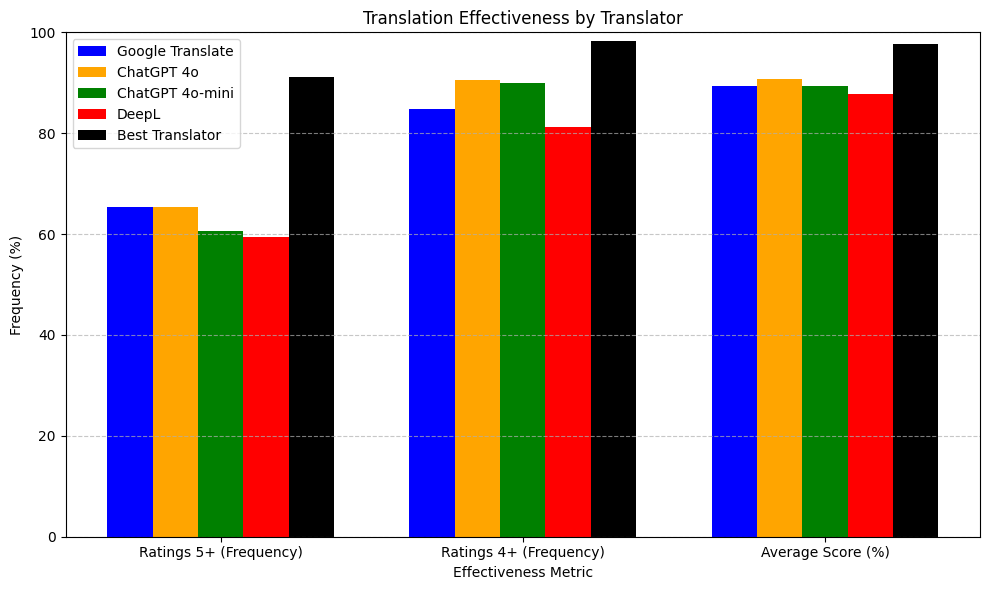

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Extract translator responses and their ratings
num_translators = 5

# Create bar positions
bar_width = 0.15
x = np.arange(3)

# Translator labels
translator_labels = ['Google Translate', 'ChatGPT 4o', 'ChatGPT 4o-mini', 'DeepL', 'Best Translator']
colors = ['blue', 'orange', 'green', 'red', 'black']

# Plot bars
plt.figure(figsize=(10, 6))

for i in range(num_translators):
    cur_bar = [ratings_5plus[i], ratings_4plus[i], ratings_average[i]]
    print(cur_bar)
    plt.bar(x + i * bar_width, cur_bar, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), ['Ratings 5+ (Frequency)', 'Ratings 4+ (Frequency)', 'Average Score (%)'])  # Center tick labels
plt.xlabel('Effectiveness Metric')
plt.ylabel('Frequency (%)')
plt.ylim(0, 100)
plt.title('Translation Effectiveness by Translator')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_effectiveness-bargraph')
plt.show()


In [ ]:
numpy_array2 = numpy_array
for row in numpy_array:
    for i in range(num_translators):
        ratings[i].append(row[5 + 2 * i])  # Extract ratings

[0.0, 3.5294117647058822, 11.76470588235294, 19.411764705882355, 65.29411764705883]
[0.0, 2.3529411764705883, 7.0588235294117645, 25.294117647058822, 65.29411764705883]
[0.0, 3.5294117647058822, 6.470588235294119, 29.411764705882355, 60.588235294117645]
[0.0, 1.7647058823529411, 17.058823529411764, 21.764705882352942, 59.411764705882355]
[0.0, 1.1764705882352942, 0.5882352941176471, 7.0588235294117645, 91.17647058823529]


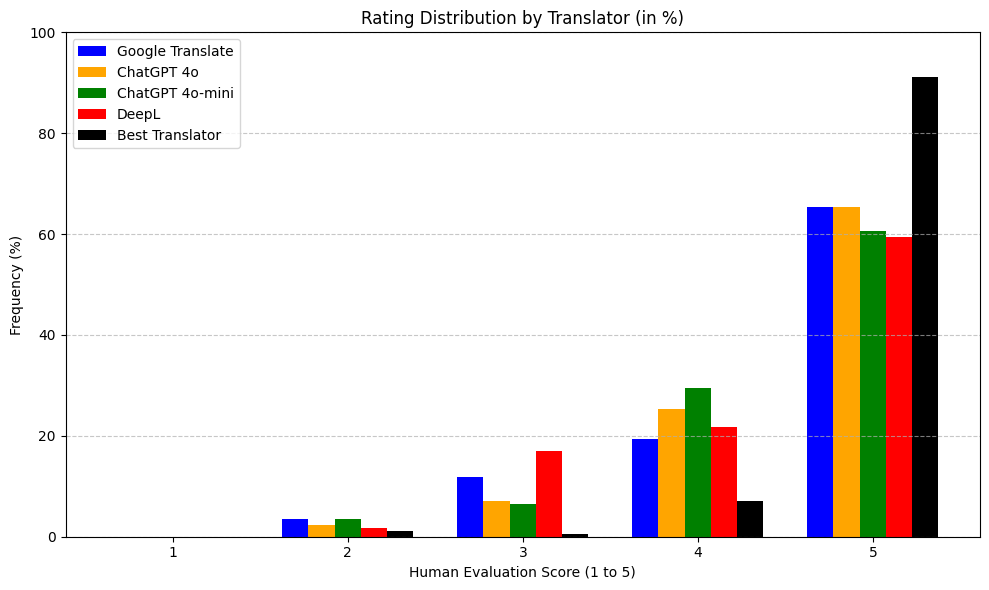

[0.0, 3.5294117647058822, 11.76470588235294, 19.411764705882355, 65.29411764705883]
[0.0, 2.3529411764705883, 7.0588235294117645, 25.294117647058822, 65.29411764705883]
[0.0, 3.5294117647058822, 6.470588235294119, 29.411764705882355, 60.588235294117645]
[0.0, 1.7647058823529411, 17.058823529411764, 21.764705882352942, 59.411764705882355]


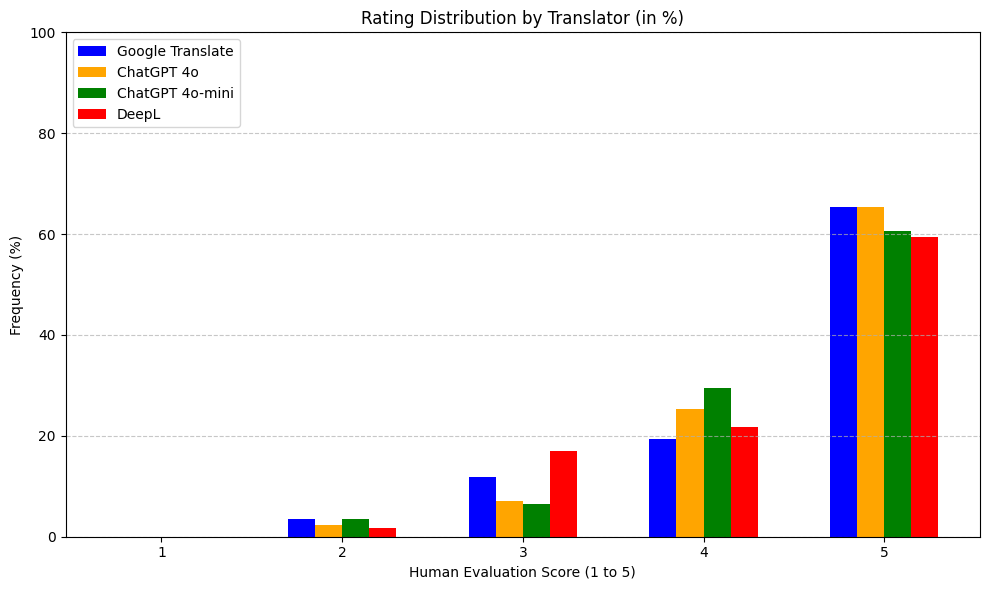

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array2  # Ensure the correct variable is used

# Extract translator responses and their ratings
num_translators = 5 # added 1 for the max
ratings = [[] for _ in range(num_translators)]

for row in numpy_array:
    max_rating = 0
    for i in range(num_translators - 1):
        cur_rating = row[5 + 2 * i]
        ratings[i].append(cur_rating)  # Extract ratings
        if (cur_rating) > max_rating:
            max_rating = cur_rating
    ratings[4].append(max_rating)

# Count occurrences of each rating (1-5) for each translator
score_range = range(1, 6)
rating_counts = [Counter(rating) for rating in ratings]

# Compute total ratings per translator for percentage calculation
total_ratings = [sum(counts.values()) for counts in rating_counts]

# Create bar positions
x = np.arange(len(score_range))
bar_width = 0.15

# Translator labels
translator_labels = ['Google Translate', 'ChatGPT 4o', 'ChatGPT 4o-mini', 'DeepL', 'Best Translator']
colors = ['blue', 'orange', 'green', 'red', 'black']

# Plot bars
plt.figure(figsize=(10, 6))

for i in range(num_translators):
    percentages = [
        (rating_counts[i][score] / total_ratings[i] * 100) if total_ratings[i] > 0 else 0
        for score in score_range
    ]
    print(percentages)
    plt.bar(x + i * bar_width, percentages, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), score_range)  # Center tick labels
plt.xlabel('Human Evaluation Score (1 to 5)')
plt.ylabel('Frequency (%)')
plt.ylim(0,100)
plt.title('Rating Distribution by Translator (in %)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_rating-distribution-bargraph-ideal.png')
plt.show()

# still plot the original
plt.figure(figsize=(10, 6))
num_translators = 4
for i in range(num_translators):
    percentages = [
        (rating_counts[i][score] / total_ratings[i] * 100) if total_ratings[i] > 0 else 0
        for score in score_range
    ]
    print(percentages)
    plt.bar(x + i * bar_width, percentages, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), score_range)  # Center tick labels
plt.xlabel('Human Evaluation Score (1 to 5)')
plt.ylabel('Frequency (%)')
plt.ylim(0,100)
plt.title('Rating Distribution by Translator (in %)')
plt.legend(loc="upper left")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_rating-distribution-bargraph-original.png')
plt.show()
